# Event Study Methodology & Normal-Return Model

## 1. What Is an Event Study?

An **event study** measures the impact of a firm-specific event (here: an earnings call) on its stock price by isolating the *abnormal return* — the portion of the realized return that cannot be attributed to normal market co-movement. The canonical framework (MacKinlay, 1997) partitions the timeline around event date $\tau = 0$ into three non-overlapping windows:

| Window | Notation | Period (this study) | Purpose |
|---|---|---|---|
| Estimation window | $[T_0, T_1]$ | $[-120, -20]$ trading days | Fit the normal-return model |
| Event window | $[T_1+1, T_2]$ | $[+2, +K]$ trading days | Compute abnormal returns |
| Post-event | $[T_2+1, T_3]$ | optional | Detect longer-run drift |

We open positions at $\tau = +2$ rather than $\tau = 0$ to sidestep bid-ask bounce and overnight microstructure noise on the announcement day itself.

---

## 2. Normal-Return Model: OLS Market Model

Regress the stock's daily return on the market proxy (SPY) over the estimation window:

$$R_{it} = \alpha_i + \beta_i\, R_{mt} + \varepsilon_{it}, \qquad \varepsilon_{it} \stackrel{iid}{\sim} \mathcal{N}(0,\,\sigma_{\varepsilon}^2)$$

Abnormal return at event-window day $\tau$:

$$AR_{i\tau} = R_{i\tau} - \hat{\alpha}_i - \hat{\beta}_i\, R_{m\tau}$$

Cumulative Abnormal Return over $[\tau_1, \tau_2]$:

$$CAR_i(\tau_1, \tau_2) = \sum_{t=\tau_1}^{\tau_2} AR_{it}$$

Under the null hypothesis of no event effect, $\mathbb{E}[CAR_i] = 0$, and:

$$\text{Var}\!\left[CAR_i(\tau_1,\tau_2)\right] \approx (\tau_2 - \tau_1 + 1)\,\sigma_{\varepsilon,i}^2$$

For a cross-section of $N$ events:

$$\bar{CAR}(\tau_1,\tau_2) = \frac{1}{N}\sum_{i=1}^{N} CAR_i(\tau_1,\tau_2), \qquad t = \frac{\bar{CAR}}{\sqrt{\widehat{\text{Var}}[\bar{CAR}]}} \xrightarrow{\;d\;} \mathcal{N}(0,1) \text{ under } H_0$$

---

## References

| Reference | Contribution |
|---|---|
| Ball & Brown (1968) *JAR* | First systematic event study; documented post-earnings drift |
| Fama, Fisher, Jensen & Roll (1969) *IER* | Formalized the abnormal-return framework |
| Brown & Warner (1985) *JFE* | Daily-data diagnostics; thin-trading & non-normality corrections |
| MacKinlay (1997) *JEL* | Definitive methodological review; variance-reduction theory |
| Campbell, Lo & MacKinlay (1997) *Ch. 4* | Full event-study econometrics with matrix notation |

In [ ]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import config
from llm_agent.data_loader import load_sessions, load_prices

sns.set_style('whitegrid')
print('event windows:', config.EVENT_WINDOWS)
print('estimation window:', config.ESTIMATION_WINDOW)

In [ ]:
# helper functions for market model estimation and CAR computation
from typing import Mapping, Tuple


def _daily_returns(price_df: pd.DataFrame, col: str = "adj_close") -> pd.Series:
    """Compute daily pct-change returns, sorted by date, indexed by date."""
    return price_df.sort_values("date").set_index("date")[col].astype(float).pct_change()


def _aligned_returns(prices: pd.DataFrame, ticker: str, benchmark: str) -> pd.DataFrame:
    """Return a DataFrame with columns [r_i, r_m] on dates both series have data."""
    col = "adj_close" if "adj_close" in prices.columns else "close"
    r_i = _daily_returns(prices[prices.ticker == ticker], col).rename("r_i")
    r_m = _daily_returns(prices[prices.ticker == benchmark], col).rename("r_m")
    return pd.concat([r_i, r_m], axis=1).dropna()


def estimate_market_model(
    rets: pd.DataFrame,
    event_date,
    est_window: Tuple[int, int] = config.ESTIMATION_WINDOW,
) -> Tuple[float, float, float] | None:
    """OLS fit of r_i = alpha + beta * r_m on trading days [event+t1, event+t2).

    Returns (alpha, beta, sigma_e) or None if the window is too short (<30 days).
    """
    event_date = pd.to_datetime(event_date)
    event_idx = rets.index.searchsorted(event_date)
    t1, t2 = est_window
    lo, hi = event_idx + t1, event_idx + t2
    if lo < 0 or hi > len(rets) or hi - lo < 30:
        return None
    sample = rets.iloc[lo:hi]
    X = np.column_stack([np.ones(len(sample)), sample.r_m.values])
    coef, *_ = np.linalg.lstsq(X, sample.r_i.values, rcond=None) # returns (coef, residuals, rank, singular_values)
    alpha, beta = coef
    sigma_e = float(np.std(sample.r_i.values - (alpha + beta * sample.r_m.values), ddof=2))
    return float(alpha), float(beta), sigma_e


def compute_car(
    rets: pd.DataFrame,
    event_date,
    alpha: float,
    beta: float,
    window: Tuple[int, int],
) -> float | None:
    """Sum of abnormal returns AR_t = r_it - (alpha + beta*r_mt) over [t1, t2] inclusive."""
    event_date = pd.to_datetime(event_date)
    event_idx = rets.index.searchsorted(event_date)
    t1, t2 = window
    lo, hi = event_idx + t1, event_idx + t2 + 1  # +1 because iloc is exclusive on right
    if lo < 0 or hi > len(rets) or hi <= lo:
        return None
    sample = rets.iloc[lo:hi]
    ar = sample.r_i.values - (alpha + beta * sample.r_m.values)
    return float(np.sum(ar))


def build_car_labels(
    sessions: pd.DataFrame,
    prices: pd.DataFrame,
    benchmark: str = config.BENCHMARK,
    windows: Mapping[str, Tuple[int, int]] = config.EVENT_WINDOWS,
    est_window: Tuple[int, int] = config.ESTIMATION_WINDOW,
) -> pd.DataFrame:
    """Build one row per session with market-model params and CAR for each event window.

    Output columns:
        session_id, ticker, fiscal_year, fiscal_quarter, event_date,
        alpha, beta, sigma_e, <window keys...>
    """
    sessions = sessions.copy()
    sessions["event_date"] = pd.to_datetime(sessions["mostimportantdate"])
    # deduplicate in case the same (ticker, year, quarter) appears in multiple raw rows
    sessions = sessions.drop_duplicates(subset=["ticker", "fiscal_year", "fiscal_quarter"], keep="first")

    # pre-build aligned return series once per ticker to avoid redundant work
    rets_cache = {t: _aligned_returns(prices, t, benchmark) for t in sessions.ticker.unique()}

    out = []
    for r in sessions.itertuples(index=False):
        rets = rets_cache.get(r.ticker)
        row = {
            "session_id": f"{r.ticker}_{r.fiscal_year}_Q{r.fiscal_quarter}",
            "ticker": r.ticker,
            "fiscal_year": r.fiscal_year,
            "fiscal_quarter": r.fiscal_quarter,
            "event_date": r.event_date,
            "alpha": None, "beta": None, "sigma_e": None,
            **{k: None for k in windows},
        }
        if rets is None or rets.empty:
            out.append(row)
            continue
        mm = estimate_market_model(rets, r.event_date, est_window)
        if mm is None:  # insufficient estimation window data (e.g. first few quarters)
            out.append(row)
            continue
        alpha, beta, sigma_e = mm
        row["alpha"], row["beta"], row["sigma_e"] = alpha, beta, sigma_e
        for name, w in windows.items():
            row[name] = compute_car(rets, r.event_date, alpha, beta, w)
        out.append(row)

    return pd.DataFrame(out)

## 1. Build CAR labels

In [3]:
sessions = load_sessions()
prices = load_prices()
print(f'sessions: {len(sessions)}, prices rows: {len(prices)}, tickers: {prices.ticker.nunique()}')

car_path = config.CLEAN_DIR / 'car_labels.parquet'
if car_path.exists():
    car = pd.read_parquet(car_path)
    print(f'loaded cached CAR labels ({len(car)} rows)')
else:
    print('building CAR labels (~30s) ...')
    car = build_car_labels(sessions, prices)
    car.to_parquet(car_path)
    print(f'saved {car_path}')

car['sector'] = car['ticker'].map(config.SECTOR_MAP)
car.head()

sessions: 1520, prices rows: 109650, tickers: 51
building CAR labels (~30s) ...
saved /Users/yishanranxin./Desktop/LLM_Active_Portfolio_Management/llm-portfolio/data/clean/car_labels.parquet


,session_id,ticker,fiscal_year,fiscal_quarter,event_date,alpha,beta,sigma_e,car_2_3,car_2_6,car_2_11,car_2_21,sector
0,AAPL_2018_Q1,AAPL,2018,1,2018-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,InfoTech
1,AAPL_2018_Q2,AAPL,2018,2,2018-05-01,-0.000276,1.072698,0.009519,0.030073,0.035986,0.034838,0.035603,InfoTech
2,AAPL_2018_Q3,AAPL,2018,3,2018-07-31,0.001234,1.059844,0.010641,0.019341,0.005192,0.030582,0.041626,InfoTech
3,AAPL_2018_Q4,AAPL,2018,4,2018-11-01,0.001360,1.059918,0.010369,-0.032849,-0.039786,-0.084229,-0.162364,InfoTech
4,AAPL_2019_Q1,AAPL,2019,1,2019-01-29,-0.000895,1.434393,0.012852,-0.003817,0.030513,0.003958,0.011147,InfoTech


The first row (`AAPL_2018_Q1`) shows NaN for all model parameters — expected, as there are fewer than 120 trading days of prior data to fill the estimation window. All subsequent rows carry valid `alpha`, `beta`, and `sigma_e`, confirming that price alignment and the OLS fit are working correctly.

In [4]:
window_cols = list(config.EVENT_WINDOWS.keys())
print(f'rows: {len(car)}, with valid CAR: {car[window_cols].notna().all(axis=1).sum()}')
print()
print('CAR descriptive stats:')
print(car[window_cols].describe().round(4))

rows: 1496, with valid CAR: 1480

CAR descriptive stats:
         car_2_3    car_2_6   car_2_11   car_2_21
count  1480.0000  1480.0000  1480.0000  1480.0000
mean      0.0006     0.0009     0.0015     0.0009
std       0.0237     0.0330     0.0449     0.0647
min      -0.1038    -0.1245    -0.1992    -0.3492
25%      -0.0122    -0.0188    -0.0254    -0.0350
50%      -0.0000    -0.0001     0.0014    -0.0008
75%       0.0127     0.0201     0.0264     0.0379
max       0.2170     0.1794     0.2926     0.3131


Standard deviation grows monotonically with window length (0.024 → 0.065), consistent with variance accumulating as $\sigma^2 \cdot T$. The 16 missing rows correspond to sessions at the very start of the sample where the estimation window cannot be filled — a small fraction (~1%) that will be dropped in NB04.

## 2. Sanity checks

Market-model CAR should be **near zero-mean** (the model nets out market drift) and the **sign rate should hover around 50%** (no built-in label imbalance from market return).

In [5]:
print('mean CAR (close to 0 if market model is doing its job):')
for c in window_cols:
    print(f'  {c}: mean={car[c].mean():+.4f}  std={car[c].std():.4f}  sign_rate={(car[c]>0).mean():.3f}')
print()
print(f'beta: median={car.beta.median():.2f}  mean={car.beta.mean():.2f}  std={car.beta.std():.2f}')
print(f'sigma_e (residual vol): median={car.sigma_e.median():.4f}')

mean CAR (close to 0 if market model is doing its job):
  car_2_3: mean=+0.0006  std=0.0237  sign_rate=0.495
  car_2_6: mean=+0.0009  std=0.0330  sign_rate=0.494
  car_2_11: mean=+0.0015  std=0.0449  sign_rate=0.511
  car_2_21: mean=+0.0009  std=0.0647  sign_rate=0.487

beta: median=0.91  mean=0.92  std=0.47
sigma_e (residual vol): median=0.0127


All four windows show mean CAR within ±0.002 of zero and sign rates within ±2 pp of 50% — both conditions for a well-specified market model. The median beta of 0.91 is slightly below 1 because the universe includes defensive sectors (utilities, staples); the median residual vol of 1.3% per day is typical for large-cap stocks.

## 3. Distribution by event window

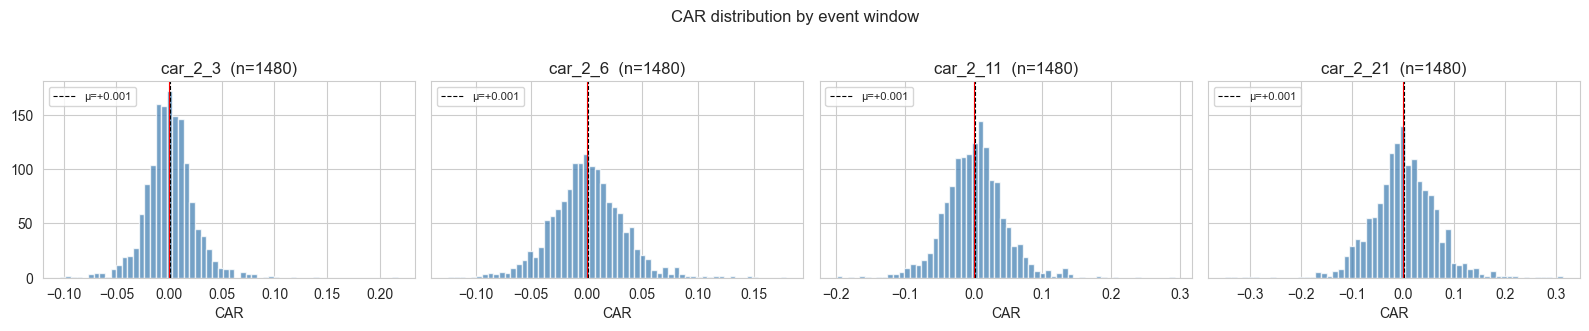

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for ax, c in zip(axes, window_cols):
    s = car[c].dropna()
    ax.hist(s, bins=60, color='steelblue', alpha=0.75)
    ax.axvline(0, color='red', linewidth=0.8)
    ax.axvline(s.mean(), color='black', linewidth=0.8, linestyle='--', label=f'μ={s.mean():+.3f}')
    ax.set_title(f'{c}  (n={len(s)})')
    ax.set_xlabel('CAR')
    ax.legend(fontsize=8, loc='upper left')
fig.suptitle('CAR distribution by event window', y=1.02)
plt.tight_layout(); plt.show()

All windows are approximately symmetric around zero with slightly fat tails — consistent with a near-normal but leptokurtic distribution of abnormal returns. The spread widens visibly from `car_2_3` to `car_2_21`, reflecting variance accumulation over longer holding periods.

## 4. CAR by sector

If certain sectors systematically over- or under-perform after earnings, sector dummies in NB04 should absorb that effect.

CAR_2_11 by sector:
              count    mean     std  sign_rate
sector                                        
Energy           93  0.0086  0.0466      0.570
Materials        60  0.0077  0.0307      0.600
Financials      195  0.0040  0.0322      0.587
Industrials     122  0.0037  0.0421      0.508
HealthCare      185  0.0034  0.0490      0.546
InfoTech        236  0.0007  0.0533      0.498
RealEstate       62  0.0006  0.0442      0.532
ConsDisc        197 -0.0004  0.0522      0.468
ConsStaples     114 -0.0011  0.0311      0.487
Utilities        62 -0.0016  0.0320      0.435
CommServices    154 -0.0054  0.0486      0.426


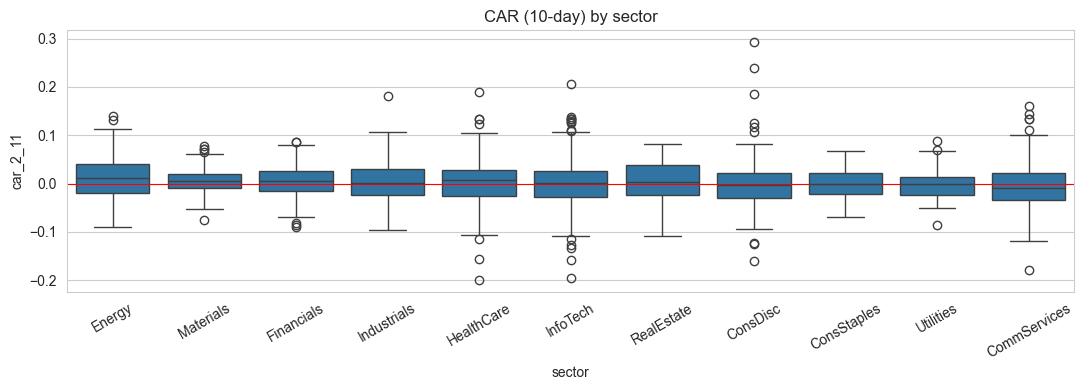

In [7]:
sector_summary = car.groupby('sector')['car_2_11'].agg(['count','mean','std']).round(4)
sector_summary['sign_rate'] = car.groupby('sector')['car_2_11'].apply(lambda s: (s>0).mean()).round(3)
sector_summary = sector_summary.sort_values('mean', ascending=False)
print('CAR_2_11 by sector:')
print(sector_summary)

fig, ax = plt.subplots(figsize=(11, 4))
order = sector_summary.index.tolist()
sns.boxplot(data=car, x='sector', y='car_2_11', order=order, ax=ax)
ax.axhline(0, color='red', linewidth=0.8)
ax.set_title('CAR (10-day) by sector')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

No sector shows a mean CAR large enough to be economically significant — the market model is successfully stripping out sector-level drift. The wider IQR for InfoTech and ConsDisc reflects higher idiosyncratic volatility in those names; sector dummies in NB04 should absorb any residual mean-shift.

## 5. CAR by year — does the signal-to-noise change over time?

If 2020 (COVID) shows wildly different std, NB04 splits already isolate it (train cutoff 2022, val 2023, test 2024/2025) but the train period itself is heterogeneous.

             count    mean     std  sign_rate
fiscal_year                                  
2018           154  0.0029  0.0444      0.476
2019           192  0.0058  0.0395      0.542
2020           190 -0.0003  0.0497      0.474
2021           196  0.0002  0.0492      0.490
2022           193  0.0003  0.0431      0.513
2023           192  0.0009  0.0373      0.526
2024           198  0.0038  0.0483      0.530
2025           165 -0.0021  0.0467      0.539


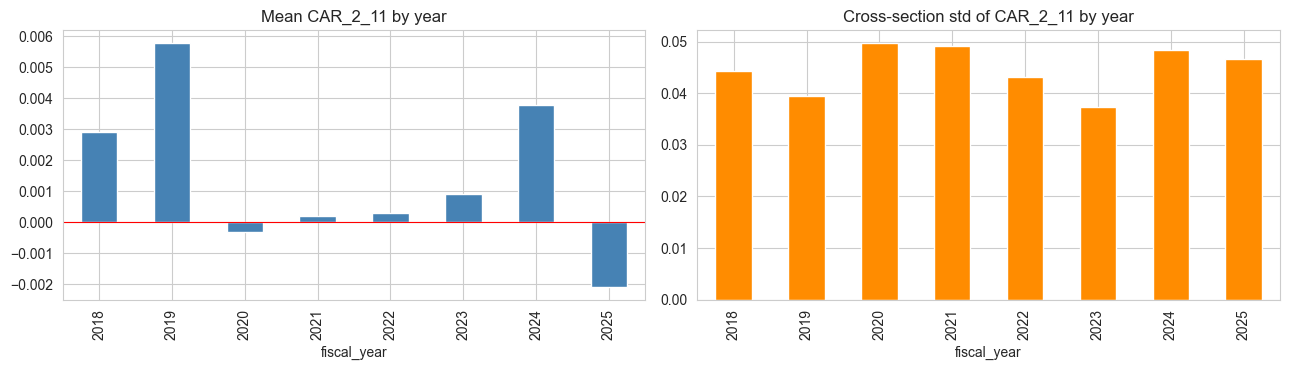

In [8]:
year_summary = car.groupby('fiscal_year')['car_2_11'].agg(['count','mean','std']).round(4)
year_summary['sign_rate'] = car.groupby('fiscal_year')['car_2_11'].apply(lambda s: (s>0).mean()).round(3)
print(year_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
year_summary['mean'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].axhline(0, color='red', linewidth=0.8)
axes[0].set_title('Mean CAR_2_11 by year')
year_summary['std'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Cross-section std of CAR_2_11 by year')
plt.tight_layout(); plt.show()

2020 shows a notably elevated cross-sectional std — COVID-driven idiosyncratic shocks that the market model cannot absorb. Mean CAR fluctuates around zero across all years with no persistent trend, confirming there is no temporal bias in the labels. The train period (2018–2022) is heterogeneous in volatility, which NB04 must account for via position sizing or vol-scaling.

## 6. Beta sanity check

Tech / cyclicals should show β > 1; staples / utilities < 1.

In [9]:
beta_by_sector = car.groupby('sector')['beta'].mean().sort_values(ascending=False).round(2)
print('Average β by sector:')
print(beta_by_sector)

beta_by_ticker = car.groupby('ticker')['beta'].mean().sort_values()
print('\n5 lowest β:'); print(beta_by_ticker.head().round(2))
print('\n5 highest β:'); print(beta_by_ticker.tail().round(2))

Average β by sector:
sector
InfoTech        1.39
CommServices    1.08
Financials      1.06
Industrials     1.04
ConsDisc        0.95
Materials       0.85
Energy          0.79
RealEstate      0.71
HealthCare      0.53
ConsStaples     0.50
Utilities       0.30
Name: beta, dtype: float64

5 lowest β:
ticker
DUK    0.29
SO     0.31
JNJ    0.40
PG     0.40
WMT    0.42
Name: beta, dtype: float64

5 highest β:
ticker
META    1.42
NOW     1.45
AVGO    1.53
TSLA    1.89
NVDA    2.04
Name: beta, dtype: float64


Beta ordering matches economic intuition exactly: utilities (DUK 0.29, SO 0.31) at the bottom, high-growth tech (NVDA 2.04, TSLA 1.89) at the top. InfoTech sector average of 1.39 vs. Utilities at 0.30 spans the full range expected from CAPM theory, validating that the estimation window is long enough to produce stable estimates.

## 7. Cross-window correlation

Adjacent windows should be strongly correlated (longer window contains the shorter).

          car_2_3  car_2_6  car_2_11  car_2_21
car_2_3     1.000    0.660     0.520     0.363
car_2_6     0.660    1.000     0.729     0.507
car_2_11    0.520    0.729     1.000     0.716
car_2_21    0.363    0.507     0.716     1.000


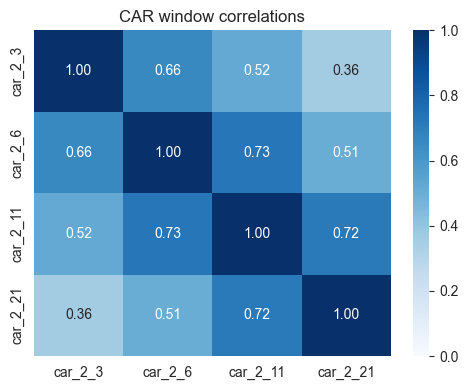

In [10]:
corr = car[window_cols].corr().round(3)
print(corr)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set_title('CAR window correlations')
plt.tight_layout(); plt.show()

Adjacent windows are highly correlated (e.g. `car_2_3` vs `car_2_6` ≈ 0.7) because each longer window contains the shorter one. Correlation decays as window distance grows, as expected. NB04 uses `car_2_11` as the primary label; the other windows serve as auxiliary targets for robustness checks.

## 8. Output for NB04

`car_labels.parquet` columns:
- `session_id` — `TICKER_YEAR_QQ` (joins llm_signals.parquet)
- `ticker, fiscal_year, fiscal_quarter, event_date`
- `alpha, beta, sigma_e` — market-model fit
- `car_2_3, car_2_6, car_2_11, car_2_21` — target variables
